# VP-SDE U-Net on CIFAR-10 Birds without Augmentation

Train and evaluate a continuous VP-SDE model with a custom U-Net on plain CIFAR-10 bird images.


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import tqdm

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Imports


In [ ]:
from google.colab import drive
import os
import sys
path = "/content/drive/MyDrive/DD2424/Project" #Folder path

drive.mount('/content/drive')
os.makedirs(path, exist_ok=True)
os.listdir(path)
project_root = os.path.dirname(path) if os.path.basename(path) == "working_nets" else path
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if path not in sys.path:
    sys.path.insert(0, path)


Mounted at /content/drive


In [ ]:
from src.plotting import denormalize, imshow, show_batch_from_loader, show_images
from src.sde import update_ema


## Load CIFAR-10 Data


In [ ]:
transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size=128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

target_idx = trainset.classes.index("bird")

train_indices = [i for i, label in enumerate(trainset.targets)
if label == target_idx]

trainset = Subset(trainset, train_indices)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

test_indices = [i for i, label in enumerate(testset.targets) if label == target_idx]

testset = Subset(testset, test_indices)


testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=4)

#Make data on device for CUDA


100%|██████████| 170M/170M [00:19<00:00, 8.96MB/s]


## U-Net Architecture


In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    """
    Time embedding as in "Attention Is All You Need"
    """
    def __init__(self, dim):
        super().__init__()
        self.dim=dim

    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        return emb


class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(32, ch)
        self.q = nn.Conv2d(ch, ch, 1)
        self.k = nn.Conv2d(ch, ch, 1)
        self.v = nn.Conv2d(ch, ch, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)

        q = self.q(h).reshape(B, C, H * W).permute(0, 2, 1)
        k = self.k(h).reshape(B, C, H * W)
        v = self.v(h).reshape(B, C, H * W)

        attn = torch.softmax(q @ k / math.sqrt(C), dim=-1)
        out = (v @ attn.permute(0, 2, 1)).reshape(B, C, H, W)

        return x + self.proj(out)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()

        self.norm1 = nn.GroupNorm(32, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(32, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.emb_proj = nn.Linear(emb_dim, out_ch * 2)
        self.act = nn.SiLU()

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(self.act(self.norm1(x)))

        scale, shift = self.emb_proj(emb).chunk(2, dim=1)
        scale = scale[:, :, None, None]
        shift = shift[:, :, None, None]

        h = self.norm2(h)
        h = h * (1 + scale) + shift
        h = self.conv2(self.act(h))

        return h + self.skip(x)


class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.ConvTranspose2d(ch, ch, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, img_ch=3, base_ch=128):
        super().__init__()

        emb_dim = base_ch * 4

        self.time_emb = SinusoidalTimeEmbedding(emb_dim)

        self.emb_mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim)
        )

        self.conv_in = nn.Conv2d(img_ch, base_ch, 3, padding=1)

        # Encoder
        self.down1 = ResBlock(base_ch, 128, emb_dim)
        self.ds0 = Downsample(128)

        self.down2 = ResBlock(128, 256, emb_dim)
        self.ds1 = Downsample(256)

        self.down3 = ResBlock(256, 512, emb_dim)
        self.attn16 = SelfAttention(512)
        self.ds2 = Downsample(512)

        self.down4 = ResBlock(512, 512, emb_dim)
        self.attn8 = SelfAttention(512)

        # Bottleneck
        self.mid1 = ResBlock(512, 512, emb_dim)
        self.mid_attn = SelfAttention(512)
        self.mid2 = ResBlock(512, 512, emb_dim)

        # Decoder
        self.up4 = ResBlock(1024, 512, emb_dim)
        self.attn8_up = SelfAttention(512)
        self.us2 = Upsample(512)

        self.up3 = ResBlock(1024, 512, emb_dim)
        self.attn16_up = SelfAttention(512)
        self.us1 = Upsample(512)

        self.up2 = ResBlock(768, 256, emb_dim)
        self.us0 = Upsample(256)

        self.up1 = ResBlock(384, 128, emb_dim)

        self.conv_out = nn.Conv2d(128, img_ch, 3, padding=1)

    def forward(self, x, t):
        emb = self.emb_mlp(self.time_emb(t * 999.0))

        x = self.conv_in(x)

        d1 = self.down1(x, emb)
        d1_down = self.ds0(d1)

        d2 = self.down2(d1_down, emb)
        d2_down = self.ds1(d2)

        d3 = self.down3(d2_down, emb)
        d3 = self.attn16(d3)
        d3_down = self.ds2(d3)

        d4 = self.down4(d3_down, emb)
        d4 = self.attn8(d4)

        mid = self.mid1(d4, emb)
        mid = self.mid_attn(mid)
        mid = self.mid2(mid, emb)

        u4 = self.up4(torch.cat([mid, d4], dim=1), emb)
        u4 = self.attn8_up(u4)
        u4_up = self.us2(u4)

        u3 = self.up3(torch.cat([u4_up, d3], dim=1), emb)
        u3 = self.attn16_up(u3)
        u3_up = self.us1(u3)

        u2 = self.up2(torch.cat([u3_up, d2], dim=1), emb)
        u2_up = self.us0(u2)

        u1 = self.up1(torch.cat([u2_up, d1], dim=1), emb)

        return self.conv_out(u1)


## VP-SDE Objective

$p_{0 t}\left(x_t \mid x_0\right)=\mathcal{N}\left(x_t ; \alpha(t) x_0, \sigma^2(t) I\right)$

## Variance preserving loss:
$\mathcal{L}=\mathbb{E}_{t, x_0, z}\left[\lambda(t)\left\|s_\theta\left(x_t, t\right)-\nabla_{x_t} \log p_{0 t}\left(x_t \mid x_0\right)\right\|^2\right]$


In [ ]:
bar_b_min = 0.1
bar_b_max = 20.0

def perturbation_kernel(t, x0):
    integral_beta = bar_b_min * t + 0.5 * (bar_b_max - bar_b_min) * t ** 2
    mean = torch.exp(-0.5 * integral_beta).view(-1, 1, 1, 1) * x0
    std = torch.sqrt(1.0 - torch.exp(-integral_beta)).view(-1, 1, 1, 1)
    return mean, std


def vp_loss(x0, net):
    """Continuous VP-SDE denoising score-matching loss."""
    B = x0.shape[0]
    eps=1e-5
    t = torch.rand(B, device=device) * (1.0 - eps) + eps
    z = torch.randn_like(x0)

    mean, std = perturbation_kernel(t, x0)
    x_t = mean + std * z

    score_target = -z / std
    score_pred = net(x_t, t)
    loss = (std ** 2 * ((score_pred - score_target) ** 2)).mean()
    return loss


def beta_t(t):
    return bar_b_min + t * (bar_b_max - bar_b_min)


## Visualize Training Images


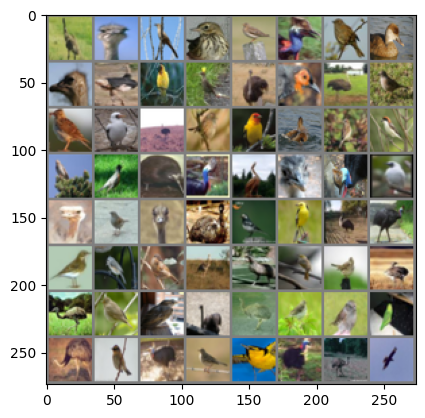

In [ ]:
real_images, _ = next(iter(trainloader))
imshow(torchvision.utils.make_grid(real_images[:64], nrow=8))


## Beta Schedule


In [ ]:
def beta_t(t):
    return bar_b_min + t * (bar_b_max - bar_b_min)


## EMA Training Setup


In [ ]:
import copy

vp_net = UNet().to(device)

ema_net = copy.deepcopy(vp_net).to(device)
ema_net.eval()

for p in ema_net.parameters():
    p.requires_grad_(False)


learning_rate = 1e-4
weight_decay=1e-4
ema_decay=0.999

optimizer = optim.AdamW(vp_net.parameters(), lr=learning_rate, weight_decay=weight_decay)

loss_hist = []
epochs=5128

for epoch in tqdm.tqdm(range(epochs)):
    vp_net.train()
    epoch_losses = []

    for i, (images, _) in enumerate(trainloader):
        images = images.to(device)

        loss = vp_loss(images, vp_net)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vp_net.parameters(), max_norm=1.0)
        optimizer.step()

        update_ema(ema_net, vp_net, decay=ema_decay)

        loss_hist.append(loss.item())
        epoch_losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"VP epoch {epoch} | Mean loss {np.mean(epoch_losses):.4f}")


  0%|          | 1/5128 [00:28<40:20:44, 28.33s/it]

VP epoch 0 | Mean loss 0.3152


  0%|          | 11/5128 [05:42<44:45:13, 31.49s/it]

VP epoch 10 | Mean loss 0.0464


  0%|          | 21/5128 [10:58<44:46:33, 31.56s/it]

...

VP epoch 1080 | Mean loss 0.0119


 21%|██▏       | 1091/5128 [9:34:12<35:22:57, 31.55s/it]

VP epoch 1090 | Mean loss 0.0111


 21%|██▏       | 1100/5128 [9:39:19<35:21:22, 31.60s/it]


KeyboardInterrupt: 

## Plot Training Loss


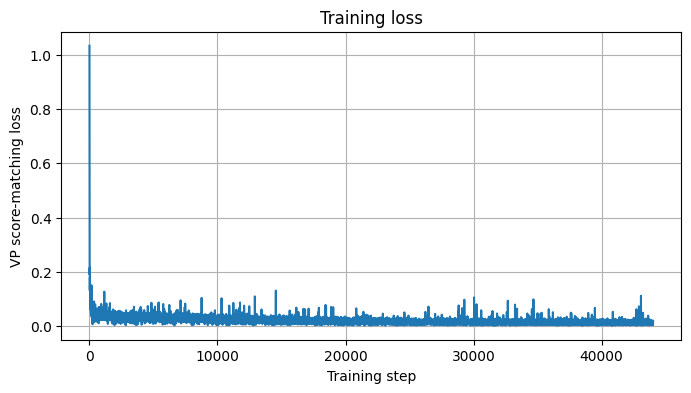

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(loss_hist)
plt.xlabel("Training step")
plt.ylabel("VP score-matching loss")
plt.title("Training loss")
plt.grid(True)
plt.show()


## Sampling


## Langevin Corrector


In [ ]:
@torch.no_grad()
def langevin_corrector_vp(x, t, net, snr=0.05, n_steps=1, eps=1e-12):

    B = x.shape[0]
    batch_t = torch.ones(B, device=device) * t

    for _ in range(n_steps):
        score = net(x, batch_t)
        noise = torch.randn_like(x)

        score_norm = torch.norm(score.reshape(B, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(B, -1), dim=1).mean()

        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2

        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


## Euler-Maruyama Predictor


In [ ]:
@torch.no_grad()
def euler_maruyama_predictor_vp(x, t, t_next, net, add_noise=True):
    B = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(B, device=device) * t

    beta = beta_t(batch_t).view(-1, 1, 1, 1)
    score = net(x, batch_t)
    drift = 0.5 * beta * x + beta * score
    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(beta * h) * noise
    else:
        x = x_mean

    return x, x_mean


## Predictor-Corrector Sampling


In [ ]:
@torch.no_grad()
def langevin_corrector_vp(x, t, net, snr=0.05, n_steps=1, eps=1e-12):
    B = x.shape[0]
    batch_t = torch.ones(B, device=device) * t

    for _ in range(n_steps):
        score = net(x, batch_t)
        noise = torch.randn_like(x)
        score_norm = torch.norm(score.reshape(B, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(B, -1), dim=1).mean()
        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2

        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


@torch.no_grad()
def euler_maruyama_predictor_vp(x, t, t_next, net, add_noise=True):
    B = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(B, device=device) * t

    beta = beta_t(batch_t).view(-1, 1, 1, 1)
    score = net(x, batch_t)
    drift = 0.5 * beta * x + beta * score
    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(beta * h) * noise
    else:
        x = x_mean

    return x, x_mean


@torch.no_grad()
def sample_pc_vp_sde_continuous(net, num_samples=64, img_shape=(3, 32, 32), num_steps=1000, eps=1e-3, snr=0.05, corrector_steps=1, denoise=True):
    net.eval()
    x = torch.randn(num_samples, *img_shape, device=device)
    timesteps = torch.linspace(1.0, eps, num_steps, device=device)
    x_mean = x

    for i in tqdm.tqdm(range(num_steps - 1)):
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_vp(x, t, net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 2
        x, x_mean = euler_maruyama_predictor_vp(x, t, t_next, net, add_noise=add_noise)

    return (x_mean if denoise else x).clamp(-1, 1)


100%|██████████| 999/999 [00:43<00:00, 22.89it/s]


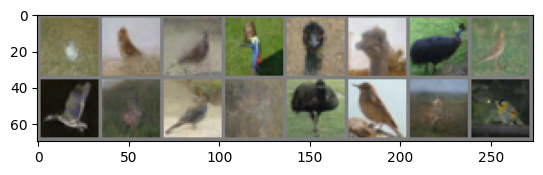

In [ ]:
samples_pc = sample_pc_vp_sde_continuous(ema_net, num_samples=16, img_shape=(3, 32, 32), num_steps=1000, eps=0.001, snr=0.01, corrector_steps=0, denoise=True)

grid = torchvision.utils.make_grid(samples_pc.detach().cpu(), nrow=8)
imshow(grid)


100%|██████████| 999/999 [01:23<00:00, 11.91it/s]


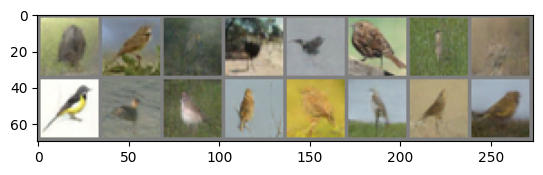

In [ ]:
samples_pc = sample_pc_vp_sde_continuous(ema_net, num_samples=16, img_shape=(3, 32, 32), num_steps=1000, eps=0.001, snr=0.01, corrector_steps=1, denoise=True)

grid = torchvision.utils.make_grid(samples_pc.detach().cpu(), nrow=8)
imshow(grid)


100%|██████████| 999/999 [02:07<00:00,  7.86it/s]


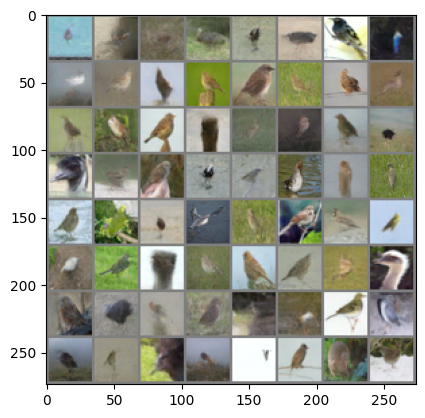

In [ ]:
samples_pc = sample_pc_vp_sde_continuous(vp_net, num_samples=64, img_shape=(3, 32, 32), num_steps=1000, eps=0.001, snr=0.016, corrector_steps=0, denoise=True)

grid = torchvision.utils.make_grid(samples_pc.detach().cpu(), nrow=8)
imshow(grid)


100%|██████████| 999/999 [01:18<00:00, 12.73it/s]


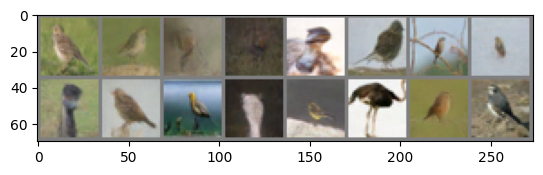

In [ ]:
samples_pc = sample_pc_vp_sde_continuous(ema_net, num_samples=16, img_shape=(3, 32, 32), num_steps=1000, eps=0.001, snr=0.016, corrector_steps=1, denoise=True)

grid = torchvision.utils.make_grid(samples_pc.detach().cpu(), nrow=8)
imshow(grid)


## Save Checkpoint


In [ ]:
"""torch.save({"vp_net": vp_net.state_dict(), "ema_net": ema_net.state_dict(), "optimizer": optimizer.state_dict(), "loss_hist": loss_hist,"epochs": epochs,"batch_size": batch_size,
"learning_rate": learning_rate,"weight_decay": weight_decay, "ema_decay": ema_decay, "bar_b_min": bar_b_min,"bar_b_max": bar_b_max,
}, path + "/bird_vp_sde_checkpoint.pth")"""


In [ ]:
checkpoint = torch.load(path + '/bird_vp_sde_checkpoint.pth', map_location=device)

vp_net2 = UNet().to(device)
ema_net2 = UNet().to(device)

vp_net2.load_state_dict(checkpoint["vp_net"])
ema_net2.load_state_dict(checkpoint["ema_net"])

vp_net2.eval()
ema_net2.eval()


UNet(
  (time_emb): SinusoidalTimeEmbedding()
  (emb_mlp): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
  )
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down1): ResBlock(
    (norm1): GroupNorm(32, 128, eps=1e-05, affine=True)
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(32, 128, eps=1e-05, affine=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (emb_proj): Linear(in_features=512, out_features=256, bias=True)
    (act): SiLU()
    (skip): Identity()
  )
  (ds0): Downsample(
    (conv): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  )
  (down2): ResBlock(
    (norm1): GroupNorm(32, 128, eps=1e-05, affine=True)
    (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(32, 256, ep

100%|██████████| 999/999 [01:06<00:00, 14.96it/s]


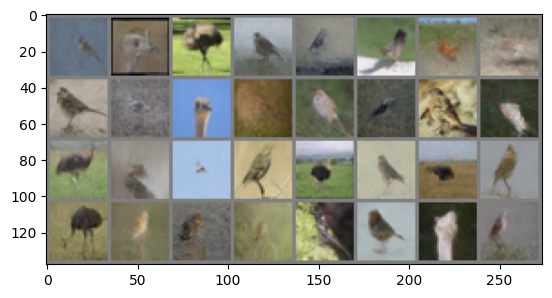

In [ ]:
samples_vp2 = sample_pc_vp_sde_continuous(vp_net2, num_samples=32, img_shape=(3, 32, 32), num_steps=1000, eps=0.001, snr=0.01, corrector_steps=0, denoise=True)

grid = torchvision.utils.make_grid(samples_vp2.detach().cpu(), nrow=8)
imshow(grid)


In [ ]:
same = True

for p1, p2 in zip(vp_net.parameters(), vp_net2.parameters()):
    if not torch.allclose(p1, p2):
        same = False
        break

print("vp_net and vp_net2 have same weights:", same)


vp_net and vp_net2 have same weights: True


## Corrector-Step Check


100%|██████████| 999/999 [00:13<00:00, 72.02it/s]


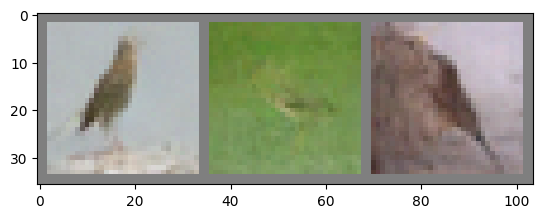

In [ ]:
samples_vp2 = sample_pc_vp_sde_continuous(vp_net2, num_samples=3, img_shape=(3, 32, 32), num_steps=1000, eps=0.001, snr=0.01, corrector_steps=0, denoise=True)

grid = torchvision.utils.make_grid(samples_vp2.detach().cpu(), nrow=8)
imshow(grid)


In [ ]:
path="/content/drive/MyDrive/DD2424/Project"


In [ ]:
checkpoint = torch.load(path + '/bird_vp_sde_checkpoint_1500_epochs.pth', map_location=device)

vp_net = UNet().to(device)
ema_net = UNet().to(device)

vp_net.load_state_dict(checkpoint["vp_net"])
ema_net.load_state_dict(checkpoint["ema_net"])

vp_net.train()
ema_net.eval()

for p in ema_net.parameters():
    p.requires_grad_(False)


In [ ]:
learning_rate = checkpoint["learning_rate"]
weight_decay=checkpoint["weight_decay"]
ema_decay=checkpoint["ema_decay"]

optimizer = optim.AdamW(vp_net.parameters(), lr=learning_rate, weight_decay=weight_decay)

optimizer.load_state_dict(checkpoint["optimizer"])


In [ ]:
for state in optimizer.state.values():
    for k, v in state.items():
        if torch.is_tensor(v):
            state[k] = v.to(device)


In [ ]:
loss_hist = checkpoint["loss_hist"]
start_epoch=1760


In [ ]:
extra_epochs = 1000

for epoch in tqdm.tqdm(range(start_epoch, start_epoch + extra_epochs)):
    vp_net.train()
    epoch_losses = []

    for i, (images, _) in enumerate(trainloader):
        images = images.to(device)

        loss = vp_loss(images, vp_net)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vp_net.parameters(), max_norm=1.0)
        optimizer.step()

        update_ema(ema_net, vp_net, decay=ema_decay)

        loss_hist.append(loss.item())
        epoch_losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"VP epoch {epoch} | Mean loss {np.mean(epoch_losses):.4f}")


  0%|          | 1/1000 [00:27<7:43:56, 27.86s/it]

VP epoch 1500 | Mean loss 0.0101


  1%|          | 11/1000 [05:36<8:40:39, 31.59s/it]

VP epoch 1510 | Mean loss 0.0083


  2%|▏         | 21/1000 [10:56<8:43:05, 32.06s/it]

...

VP epoch 1750 | Mean loss 0.0089


 26%|██▌       | 261/1000 [2:18:39<6:32:46, 31.89s/it]

VP epoch 1760 | Mean loss 0.0095


 26%|██▌       | 261/1000 [2:19:01<6:33:39, 31.96s/it]


KeyboardInterrupt: 

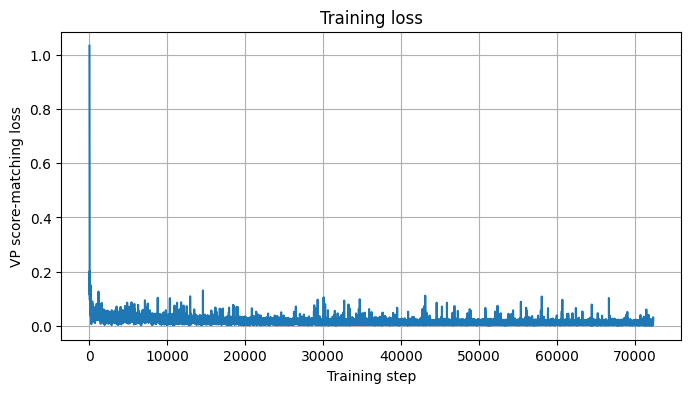

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(loss_hist)
plt.xlabel("Training step")
plt.ylabel("VP score-matching loss")
plt.title("Training loss")
plt.grid(True)
plt.show()


100%|██████████| 999/999 [01:27<00:00, 11.46it/s]


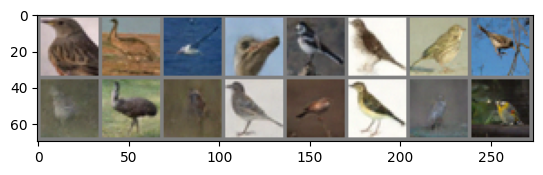

In [ ]:
samples_vp2 = sample_pc_vp_sde_continuous(vp_net, num_samples=16, img_shape=(3, 32, 32), num_steps=1000, eps=0.001, snr=0.01, corrector_steps=1, denoise=True)

grid = torchvision.utils.make_grid(samples_vp2.detach().cpu(), nrow=8)
imshow(grid)


100%|██████████| 999/999 [02:23<00:00,  6.94it/s]


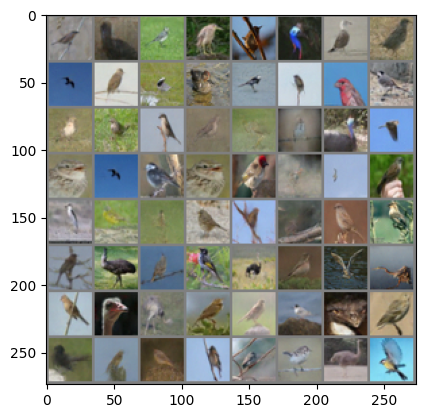

In [ ]:
samples_vp2 = sample_pc_vp_sde_continuous(vp_net, num_samples=64, img_shape=(3, 32, 32), num_steps=1000, eps=0.001, snr=0.01, corrector_steps=0, denoise=True)

grid = torchvision.utils.make_grid(samples_vp2.detach().cpu(), nrow=8)
imshow(grid)


100%|██████████| 1499/1499 [00:14<00:00, 106.08it/s]


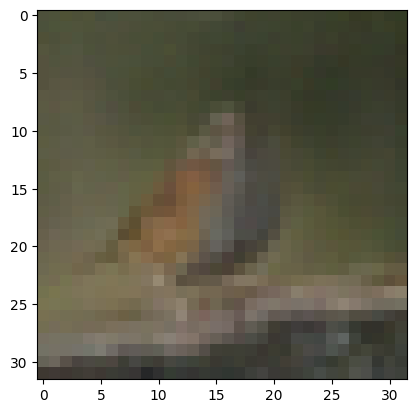

In [ ]:
samples_vp2 = sample_pc_vp_sde_continuous(vp_net, num_samples=1, img_shape=(3, 32, 32), num_steps=1500, eps=0.001, snr=0.01, corrector_steps=0, denoise=True)

grid = torchvision.utils.make_grid(samples_vp2.detach().cpu(), nrow=8)
imshow(grid)


In [ ]:
torch.save({"vp_net": vp_net.state_dict(), "ema_net": ema_net.state_dict(), "optimizer": optimizer.state_dict(), "loss_hist": loss_hist,"epochs": 1760,"batch_size": batch_size,
    "learning_rate": learning_rate,"weight_decay": weight_decay, "ema_decay": ema_decay, "bar_b_min": bar_b_min,"bar_b_max": bar_b_max,
}, path + "/bird_vp_sde_checkpoint_1760_epochs.pth")


## Imports


In [ ]:
import time
import subprocess

from torch.utils.data import Subset, DataLoader
from torchvision.utils import make_grid

def install_fid_dependencies_if_needed():
    try:
        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance
    except Exception:
        print("Installing torchmetrics and torch-fidelity...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torchmetrics', 'torch-fidelity'])

        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance


In [ ]:
install_fid_dependencies_if_needed()
#


Installing torchmetrics and torch-fidelity...


torchmetrics.image.fid.FrechetInceptionDistance

Using device: cuda
Mounted at /content/drive
Project path: /content/drive/MyDrive/DD2424/Project
Files in project path: ['bird_vp_sde_checkpoint_1335_epochs.pth', 'bird_vp_sde_checkpoint_1500_epochs.pth', 'bird_vp_sde_checkpoint_1760_epochs.pth']


100%|██████████| 170M/170M [00:02<00:00, 70.0MB/s]


Target class: bird
Target class index: 2
Number of bird training images: 5000
Number of bird test images: 1000
Steps per epoch: 40


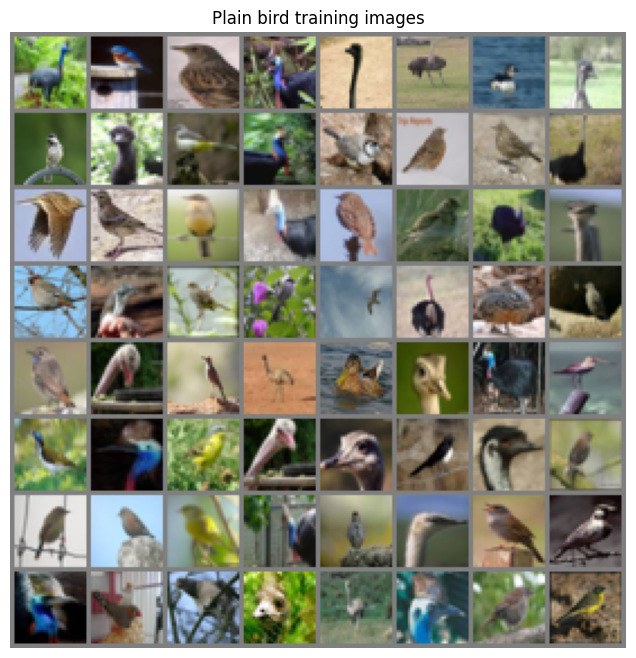

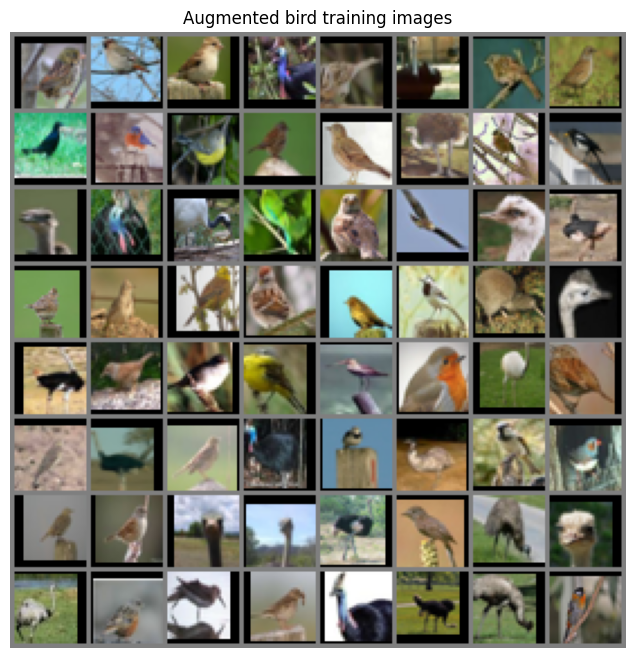

Initializing new model.
New model initialized.


  0%|          | 1/2000 [00:26<14:53:20, 26.81s/it]

VP epoch 0 | Mean loss 0.3178


  1%|          | 11/2000 [05:31<17:05:14, 30.93s/it]

VP epoch 10 | Mean loss 0.0475


...

VP epoch 1950 | Mean loss 0.0235


 98%|█████████▊| 1961/2000 [16:55:38<20:14, 31.13s/it]

VP epoch 1960 | Mean loss 0.0232


 99%|█████████▊| 1971/2000 [17:00:48<15:01, 31.07s/it]

VP epoch 1970 | Mean loss 0.0237
